# Phase 4 — Integrated Groove Profile Analysis (RQ3)

Following the extraction of temporal, dynamic and timbral descriptors in the previous phases, the final stage of the project combines these features into a unified computational representation of Herbie Hancock's performance style.

In addition to the descriptors extracted previously, this phase introduces two further musical characteristics:

- Spectral Direction (approximated from Spectral Centroid changes).
- Shannon Entropy of the Chroma distribution.

Together, these descriptors provide a multidimensional representation of expressive performance and form the basis for the final Groove Profile model.

Beyond the statistical analysis itself, the resulting Groove Profile provides a compact representation of the expressive characteristics extracted from the analyzed performances. These descriptors can subsequently be reused in downstream MIR applications and performance modeling.

## Research Question (RQ3)

How do temporal, dynamic, timbral and harmonic descriptors jointly characterize Herbie Hancock's expressive performance style?

Specifically:

- Which expressive descriptors exhibit the strongest statistical relationships?

- Does harmonic complexity relate to timing behaviour and articulation?

- Can the extracted descriptors be integrated into a unified computational Groove Profile?

## Theoretical Background

The final Groove Profile combines five complementary descriptors extracted throughout the project.

### 1. Microtiming Deviation

Microtiming deviation represents the temporal displacement between a performed note onset and the estimated beat grid.

It is defined as

$$
\Delta t_i=t_i-b_j
$$

where

- \(t_i\) denotes the detected onset;
- \(b_j\) denotes the nearest beat position.

Negative values indicate ahead-of-the-beat performance, whereas positive values indicate behind-the-beat performance.

---

### 2. RMS Energy

RMS Energy measures the average signal power within a short analysis window and serves as a continuous approximation of note intensity.

---

### 3. Spectral Centroid

Spectral Centroid represents the center of mass of the frequency spectrum and provides an estimate of perceived timbral brightness.

---

### 4. Shannon Entropy of the Chroma Distribution

To estimate harmonic complexity, Chroma features are first normalized into a probability distribution

$$
p_k(t)=
\frac{c_k(t)}
{\sum_{j=1}^{12}c_j(t)+\varepsilon}
$$

The Shannon Entropy is then computed as

$$
H_{\mathrm{chroma}}(t)
=
-\sum_{k=1}^{12}
p_k(t)
\log_2
\left(
p_k(t)+\varepsilon
\right)
$$

Higher entropy values correspond to more evenly distributed pitch-class energy and therefore greater harmonic complexity.

---

### 5. Spectral Direction

Rather than estimating melodic pitch directly, this project approximates local spectral movement using frame-to-frame changes in Spectral Centroid.

The descriptor is defined as

$$
\Delta C_i=C_i-C_{i-1}
$$

where \(C_i\) denotes the Spectral Centroid of the current onset frame.

Although this measure does not represent true melodic pitch, it provides a simple approximation of local spectral motion suitable for exploratory MIR analysis.

The following section combines all extracted descriptors into a single feature matrix.

For consistency with the previous phases, only note onsets whose microtiming deviations fall within the established ±80 ms tolerance window are retained for further analysis.

In [10]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = ['chameleon.wav', 'cantaloupe.wav', 'rockit.wav']

titles = {
    'chameleon.wav': 'Chameleon (1970s)',
    'cantaloupe.wav': 'Cantaloupe Island (1960s)',
    'rockit.wav': 'Rockit (1983)'
}

hop_length = 512
frame_length = 2048
tolerance_ms = 80.0
eps = 1e-10

full_feature_db = []


for file in files:

    path = f'../data/audio/{file}'

    y, sr = librosa.load(path, sr=None)

    onset_env = librosa.onset.onset_strength(
        y=y,
        sr=sr,
        hop_length=hop_length
    )

    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_env,
        sr=sr,
        hop_length=hop_length,
        backtrack=True
    )

    onset_times = librosa.frames_to_time(
        onset_frames,
        sr=sr,
        hop_length=hop_length
    )

    tempo, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env,
        sr=sr,
        hop_length=hop_length
    )

    beat_times = librosa.frames_to_time(
        beat_frames,
        sr=sr,
        hop_length=hop_length
    )

    rms = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=frame_length,
        hop_length=hop_length
    )[0]

    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr,
        hop_length=hop_length
    )

    chroma_prob = chroma / (
        np.sum(chroma, axis=0, keepdims=True) + eps
    )

    chroma_entropy = -np.sum(
        chroma_prob * np.log2(chroma_prob + eps),
        axis=0
    )

    if 'Cantaloupe' in titles[file]:
        era = '1960s'
    elif 'Chameleon' in titles[file]:
        era = '1970s'
    else:
        era = '1980s'

    for frame, onset in zip(onset_frames, onset_times):

        closest_beat_idx = np.argmin(np.abs(beat_times - onset))
        closest_beat = beat_times[closest_beat_idx]

        deviation_ms = (onset - closest_beat) * 1000

        if np.abs(deviation_ms) <= tolerance_ms:

            full_feature_db.append({

                'Track': titles[file],

                'Era': era,

                'Onset_Time_Sec': onset,

                'Microtiming_Dev_MS': deviation_ms,

                'RMS_Energy': rms[frame],

                'Spectral_Centroid_Hz': spectral_centroid[frame],

                'Chroma_Entropy': chroma_entropy[frame]

            })

df_full = pd.DataFrame(full_feature_db)

df_full['Spectral_Delta'] = (
    df_full
    .groupby('Era')['Spectral_Centroid_Hz']
    .diff()
    .fillna(0)
)

print(f"Successfully extracted {len(df_full)} expressive note events across 3 eras.")

print("\nPreview of extracted features:")

print(df_full.head())

Successfully extracted 277 expressive note events across 3 eras.

Preview of extracted features:
               Track    Era  Onset_Time_Sec  Microtiming_Dev_MS  RMS_Energy  \
0  Chameleon (1970s)  1970s        0.487619          -23.219955    0.290424   
1  Chameleon (1970s)  1970s        1.079728          -11.609977    0.415022   
2  Chameleon (1970s)  1970s        1.648617          -23.219955    0.114656   
3  Chameleon (1970s)  1970s        2.194286          -23.219955    0.108654   
4  Chameleon (1970s)  1970s        2.751565          -23.219955    0.253083   

   Spectral_Centroid_Hz  Chroma_Entropy  Spectral_Delta  
0           2629.293779        3.549663        0.000000  
1           3201.209068        3.417248      571.915289  
2           6414.591566        3.443605     3213.382498  
3           6616.826609        3.418494      202.235042  
4           2469.226759        3.536439    -4147.599850  


## Correlation Analysis

To investigate the relationships between the extracted descriptors, both **Pearson** and **Spearman** correlation matrices are computed.

Pearson's correlation coefficient measures linear relationships between continuous variables, whereas Spearman's rank correlation coefficient captures monotonic relationships that may not necessarily be linear.

Together, these complementary statistics provide an overview of how the temporal, dynamic, timbral and harmonic descriptors interact within the proposed Groove Profile.

In [11]:
features = [
    'Microtiming_Dev_MS',
    'RMS_Energy',
    'Spectral_Centroid_Hz',
    'Chroma_Entropy',
    'Spectral_Delta'
]

corr_pearson = df_full[features].corr(method='pearson')
corr_spearman = df_full[features].corr(method='spearman')

print("\n--- Pearson Correlation Matrix ---")
print(corr_pearson.round(3))

print("\n--- Spearman Correlation Matrix ---")
print(corr_spearman.round(3))


--- Pearson Correlation Matrix ---
                      Microtiming_Dev_MS  RMS_Energy  Spectral_Centroid_Hz  \
Microtiming_Dev_MS                 1.000       0.253                 0.228   
RMS_Energy                         0.253       1.000                -0.216   
Spectral_Centroid_Hz               0.228      -0.216                 1.000   
Chroma_Entropy                     0.102       0.066                -0.025   
Spectral_Delta                     0.090      -0.081                 0.696   

                      Chroma_Entropy  Spectral_Delta  
Microtiming_Dev_MS             0.102           0.090  
RMS_Energy                     0.066          -0.081  
Spectral_Centroid_Hz          -0.025           0.696  
Chroma_Entropy                 1.000           0.026  
Spectral_Delta                 0.026           1.000  

--- Spearman Correlation Matrix ---
                      Microtiming_Dev_MS  RMS_Energy  Spectral_Centroid_Hz  \
Microtiming_Dev_MS                 1.000       0.3

The numerical correlation coefficients provide a quantitative summary of pairwise relationships between the extracted descriptors.

To facilitate interpretation, the following visualization presents the Spearman correlation matrix, highlighting the strength and direction of monotonic associations between the different expressive features.

## Feature Correlation Matrix

The heatmap summarizes the strength of pairwise relationships between all extracted descriptors.

Warm colors indicate positive correlations, whereas cool colors indicate negative correlations.

Because Spearman's coefficient is based on ranked observations, it provides a more robust description of musical performance data, which often exhibit non-linear behaviour and non-Gaussian distributions.

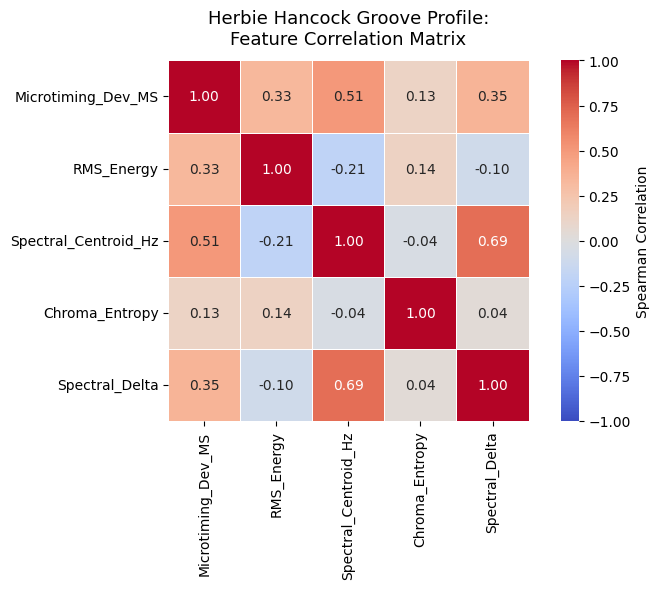

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman Correlation'}
)

plt.title(
    "Herbie Hancock Groove Profile:\nFeature Correlation Matrix",
    fontsize=13,
    pad=12
)

plt.tight_layout()

plt.savefig(
    "../data/processed/final_correlation_matrix.png",
    dpi=300
)

plt.show()

## Interpretation

The correlation matrix indicates that the extracted descriptors capture complementary aspects of expressive performance rather than measuring the same musical phenomenon.

Several observations can be made.

- **Microtiming Deviation** exhibits moderate positive correlations with both **Spectral Centroid** (ρ = 0.51) and **Spectral Delta** (ρ = 0.35), suggesting that timing behaviour is partially associated with changes in spectral brightness.

- **RMS Energy** shows only weak relationships with the remaining descriptors and a small negative association with **Spectral Centroid** (ρ = −0.21), indicating that louder note attacks do not necessarily correspond to brighter spectra in the analyzed recordings.

- **Spectral Centroid** and **Spectral Delta** demonstrate the strongest observed relationship (ρ = 0.69), which is expected since both descriptors are derived from spectral characteristics of the signal.

- **Chroma Entropy** remains only weakly correlated with the remaining variables (|ρ| < 0.15), suggesting that harmonic complexity provides information largely independent of timing, dynamics and timbre.

Overall, the observed correlations suggest that expressive performance is better described as a multidimensional phenomenon, with timing, dynamics, timbre and harmonic complexity contributing complementary information.

## Discussion

The obtained correlations indicate that no single descriptor dominates the proposed Groove Profile. Instead, timing behaviour, dynamic articulation, timbral brightness and harmonic complexity each contribute complementary information regarding expressive performance.

Because the analysis relies on a small corpus of representative recordings, the reported correlations should be interpreted as exploratory rather than definitive performer-specific estimates.

The generally modest correlation values suggest that these descriptors characterize different dimensions of musical expression rather than duplicating one another. This observation supports the multidimensional Groove Profile developed throughout the project.

Although the analysis is based on a limited corpus of representative recordings, the adopted methodology demonstrates how multiple MIR descriptors can be integrated into a coherent statistical representation of expressive keyboard performance.

## Conclusion

Phase 4 combines all extracted descriptors into a unified Groove Profile.

The resulting feature set summarizes temporal, dynamic, timbral and harmonic characteristics of the analyzed recordings and demonstrates how Music Information Retrieval techniques can quantify expressive performance.

The integrated Groove Profile provides a compact statistical representation that serves as the principal outcome of the analytical component of this project.